<a href="https://colab.research.google.com/github/aleakucing/PCVK26_14_IBRA/blob/main/Week3_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

link:

https://colab.research.google.com/drive/12Biv6OSa-FiOBclcJlvEVO3H2cQpUy7d?usp=sharing

In [46]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Muchammad Ibrahim Al Amin'
NIM = '244107020062'

N = int(NIM[-3:])

PARAM = {
'b' : (N % 61) + 20,
'a' : round(1.0 + (N % 9) / 10, 1),
'c' : (N % 20) + 30,
'gamma': round(0.4 + (N % 6) * 0.25, 2),
'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])





NAMA : Muchammad Ibrahim Al Amin
NIM : 244107020062 | N = 62
b      : 21
a      : 1.8
c      : 32
gamma  : 0.9
bit    : 4
WAKTU : 2026-09-18 16:08:36 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 00bd32cae0bf0a4c


In [47]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Mengubah Tingkat Kecerahan Citra
--------------------------------
Masukkan Nilai Kecerahan: 30


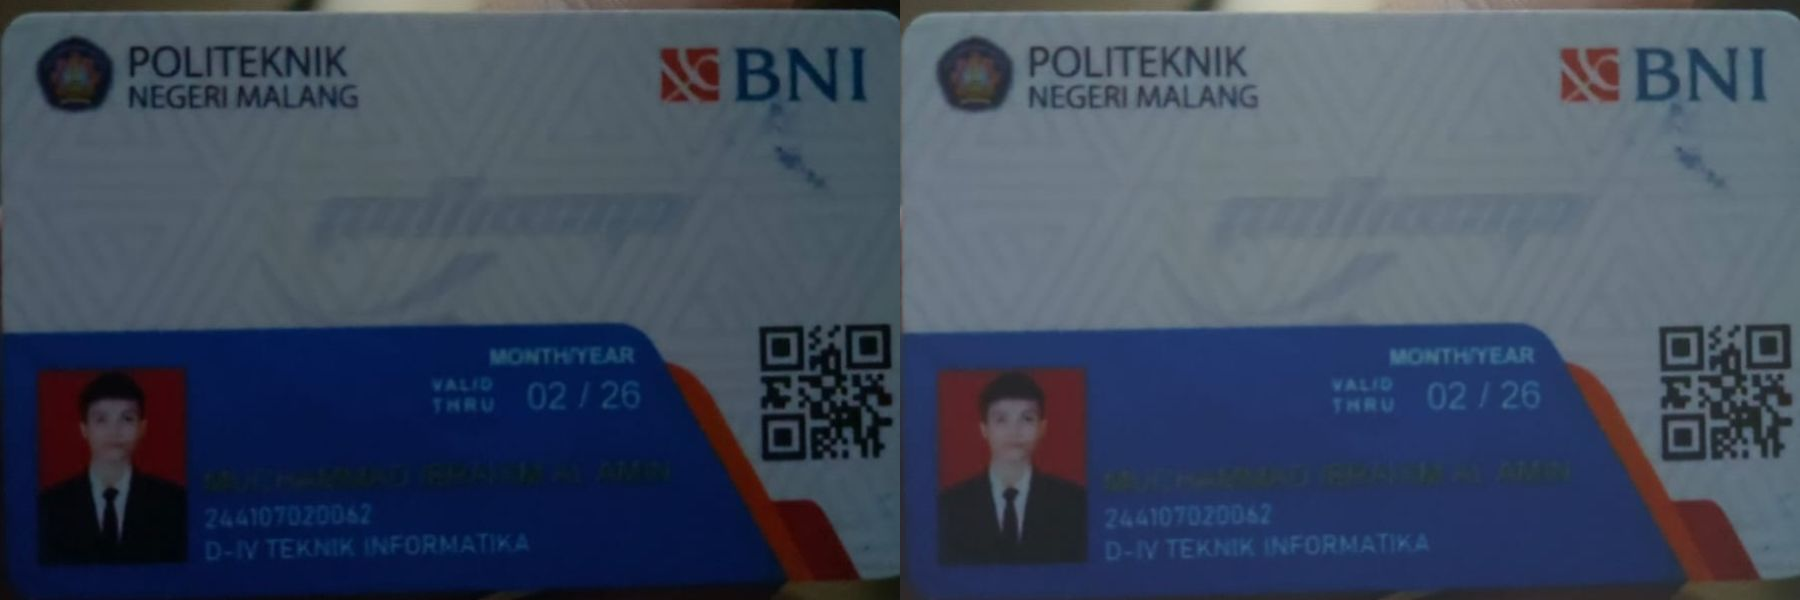

In [48]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


print('Mengubah Tingkat Kecerahan Citra')
print('--------------------------------')

try:
  brightness = int(input("Masukkan Nilai Kecerahan: "))
except ValueError:
  print('Error, Not a number')

original = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/KTM1a.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range (original.shape[0]):
  for x in range (original.shape[1]):
    for c in range (original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)

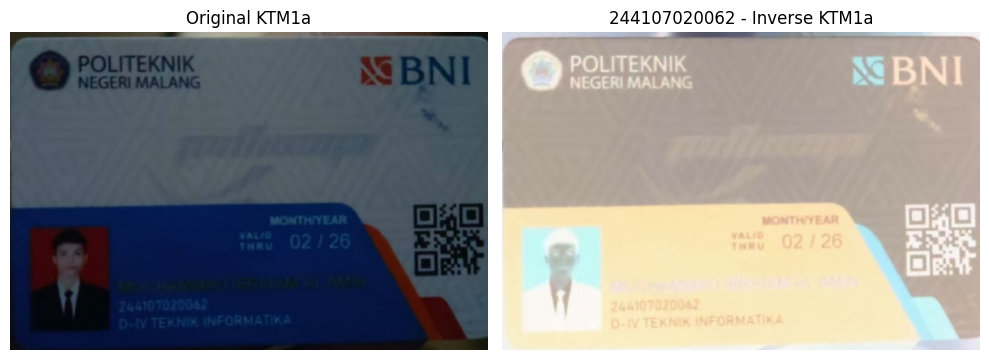

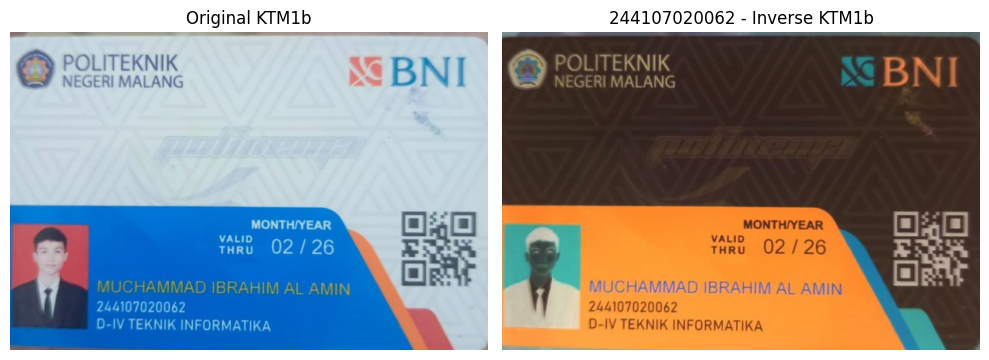

In [49]:
#tugas pratikum

#1

foto_b = original = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/KTM1b.jpg')
foto_a = original = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/KTM1a.jpg')

foto_a_rgb = cv.cvtColor(foto_a, cv.COLOR_BGR2RGB)
foto_b_rgb = cv.cvtColor(foto_b, cv.COLOR_BGR2RGB)

negative_a = 255 - foto_a_rgb
negative_b = 255 - foto_b_rgb

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original KTM1a")
plt.imshow(foto_a_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"{NIM} - Inverse KTM1a")
plt.imshow(negative_a)
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Original KTM1b")
plt.imshow(foto_b_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"{NIM} - Inverse KTM1b")
plt.imshow(negative_b)
plt.axis('off')

plt.tight_layout()
plt.show()

Penjelasan

- KTM1a : karena pixel pada citra didominasi dengan insensitas mendekati 0, maka saat dilakukan inversi sebagian besar pixel akan berubah menjadi lebih tinggi atau mendekati 255, Karena variasi intensitasnya menyempit di daerah terang tanpa area gelap yang seimbang, citra tampak datar, memudar, berkabut, dan kehilangan kontras.

- KTM1B : karena piksel memiliki sebaran intensitas yang seimbang antara gelap, sedang, dan terang. Saat diinversi, perbedaan kontras antarpiksel tetap terjaga dengan baik, sehingga citra negatifnya tetap tajam dan kontras

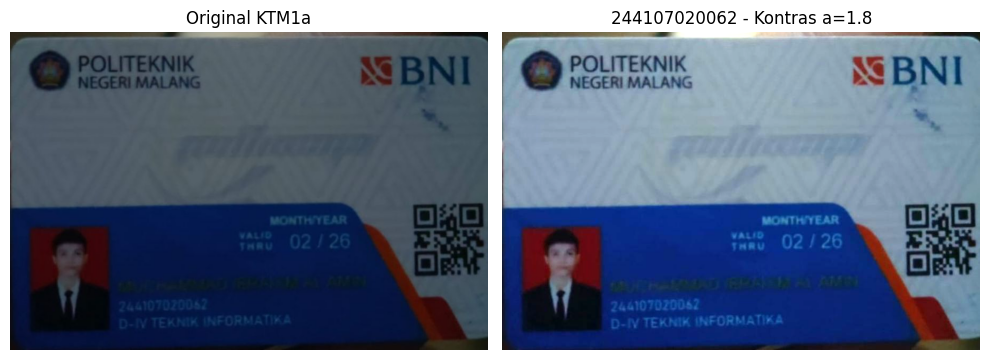

In [50]:
#2. Implementasikan transformasi kontras dengan nilai a yang dihitung dari NIM Anda(PARAM['a']) pada KTM1a.jpg.

foto_a2 = original = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/KTM1a.jpg')
a = PARAM['a']
kontras = np.zeros(foto_a.shape, foto_a.dtype)

for y in range(foto_a.shape[0]):
  for x in range(foto_a.shape[1]):
    for c in range(foto_a.shape[2]):
      kontras[y, x, c] = np.clip( int(foto_a[y,x,c]) * a, 0, 255)

foto_a_rgb = cv.cvtColor(foto_a, cv.COLOR_BGR2RGB)
kontras_rgb = cv.cvtColor(kontras, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original KTM1a")
plt.imshow(foto_a_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"{NIM} - Kontras a={PARAM['a']}")
plt.imshow(kontras_rgb)
plt.axis('off')

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(899.5), np.float64(599.5), np.float64(-0.5))

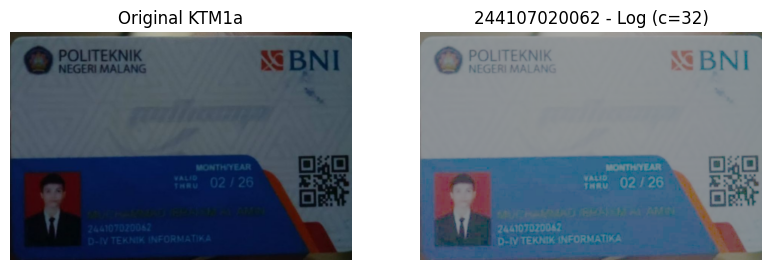

In [51]:
# 3. IMPLEMENTASI TRANSFORMASI LOGARITHMIC BRIGHTNESS

foto_a3 = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/KTM1a.jpg')
foto_rgb3 = cv.cvtColor(foto_a3, cv.COLOR_BGR2RGB)

b = PARAM['b']
c = PARAM['c']

foto_float = foto_rgb3.astype('float32')
log_brightness = np.zeros(foto_rgb3.shape, foto_rgb3.dtype)

foto_log = c * np.log(1.0 + foto_float)
log_result = np.uint8(np.clip(foto_log, 0, 255))

linear_transformed = foto_float + b
linear_result = np.uint8(np.clip(linear_transformed, 0, 255))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original KTM1a")
plt.imshow(foto_rgb3)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"{NIM} - Log (c={c})")
plt.imshow(log_result)
plt.axis('off')




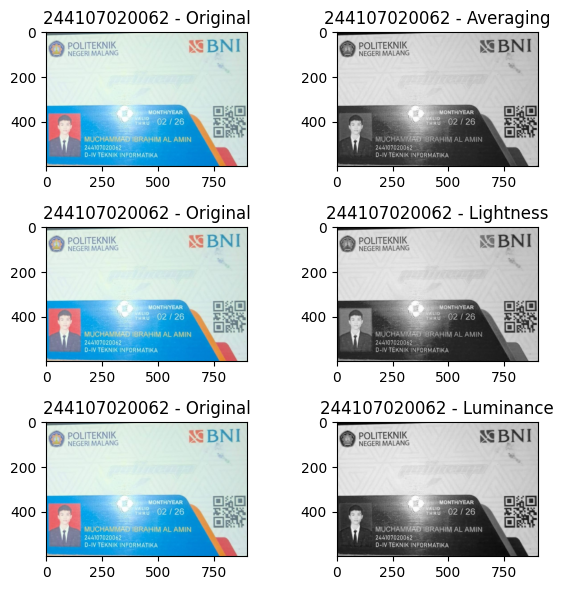

In [52]:
# 4. IMPLEMENTASI grayscale metode averaging, lightness, dan luminance
foto_a4 = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/KTM1c.jpg')
foto_rgb4 = cv.cvtColor(foto_a4, cv.COLOR_BGR2RGB)

foto_float = foto_rgb4.astype('float32')

#Gray Avg
gray_avg = np.mean(foto_float, axis=2)
gray_avg = np.uint8(np.clip(gray_avg, 0, 255))

#Gray Light
max_val = np.max(foto_float, axis=2)  # Hindari nama variabel 'max'
min_val = np.min(foto_float, axis=2)  # Hindari nama variabel 'min'
gray_lightness = (max_val + min_val) / 2.0
gray_lightness = np.uint8(np.clip(gray_lightness, 0, 255))

#Gray Lumi
k1 = 0.21
k2 = 0.72
k3 = 0.07
gray_luminance = k1 * foto_float[:, :, 0] + k2 * foto_float[:, :, 1] + k3 * foto_float[:, :, 2]
gray_lumi = np.uint8(np.clip(gray_luminance, 0, 255))

plt.figure(figsize=(6, 6))

plt.subplot(3, 2, 1)
plt.title(f"{NIM} - Original")
plt.imshow(foto_rgb4)
plt.axis('on')

plt.subplot(3, 2, 2)
plt.title(f"{NIM} - Average")
plt.imshow(gray_avg, cmap='gray')
plt.axis('on')

plt.subplot(3, 2, 3)
plt.title(f"{NIM} - Original")
plt.imshow(foto_rgb4)
plt.axis('on')

plt.subplot(3, 2, 4)
plt.title(f"{NIM} - Lightness")
plt.imshow(gray_lightness, cmap='gray')
plt.axis('on')

plt.subplot(3, 2, 5)
plt.title(f"{NIM} - Original")
plt.imshow(foto_rgb4)
plt.axis('on')

plt.subplot(3, 2, 6)
plt.title(f"{NIM} - Luminance")
plt.imshow(gray_lumi, cmap='gray')
plt.axis('on')

plt.tight_layout()
plt.show()


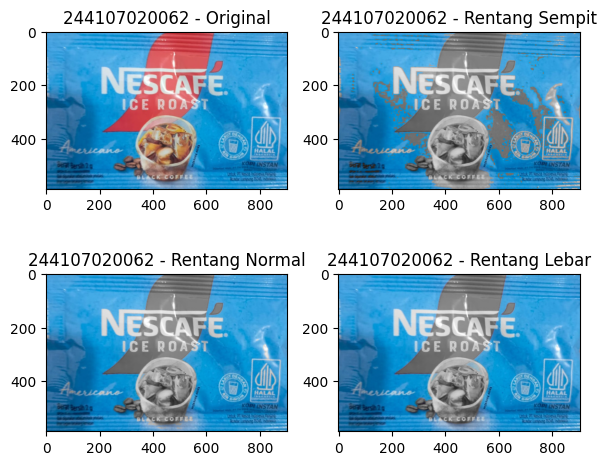

In [63]:
#5. Grayscale Mengguankan OBJ1
foto_bgr = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/OBJ1.jpg')
foto_rgb = cv.cvtColor(foto_bgr, cv.COLOR_BGR2RGB)
foto_hsv = cv.cvtColor(foto_bgr, cv.COLOR_BGR2HSV)

foto_gray = cv.cvtColor(foto_bgr, cv.COLOR_BGR2GRAY)
foto_gray_3ch = cv.cvtColor(foto_gray, cv.COLOR_GRAY2RGB)

#sempit
lower_sempit = np.array([100, 150, 100])
upper_sempit = np.array([120, 255, 255])

#normal
lower_normal = np.array([90, 80, 50])
upper_normal = np.array([130, 255, 255])

#lebar
lower_lebar = np.array([75, 40, 30])
upper_lebar = np.array([145, 255, 255])


mask_sempit = cv.inRange(foto_hsv, lower_sempit, upper_sempit)
mask_normal = cv.inRange(foto_hsv, lower_normal, upper_normal)
mask_lebar   = cv.inRange(foto_hsv, lower_lebar, upper_lebar)

hasil_sempit = foto_gray_3ch.copy()
hasil_sempit[mask_sempit == 255] = foto_rgb[mask_sempit == 255]

hasil_normal = foto_gray_3ch.copy()
hasil_normal[mask_normal == 255] = foto_rgb[mask_normal == 255]

hasil_lebar = foto_gray_3ch.copy()
hasil_lebar[mask_lebar == 255] = foto_rgb[mask_lebar == 255]
plt.figure(figsize=(6, 5))

plt.subplot(2, 2, 1)
plt.title(f"{NIM} - Original")
plt.imshow(foto_rgb)
plt.axis('on')

plt.subplot(2, 2, 2)
plt.title(f"{NIM} - Rentang Sempit")
plt.imshow(hasil_sempit)
plt.axis('on')

plt.subplot(2, 2, 3)
plt.title(f"{NIM} - Rentang Normal")
plt.imshow(hasil_normal)
plt.axis('on')

plt.subplot(2, 2, 4)
plt.title(f"{NIM} - Rentang Lebar")
plt.imshow(hasil_lebar)
plt.axis('on')

plt.tight_layout()
plt.show()

Mengubah Gamma Citra
--------------------------------
Masukkan Nilai Gamma: 0.4


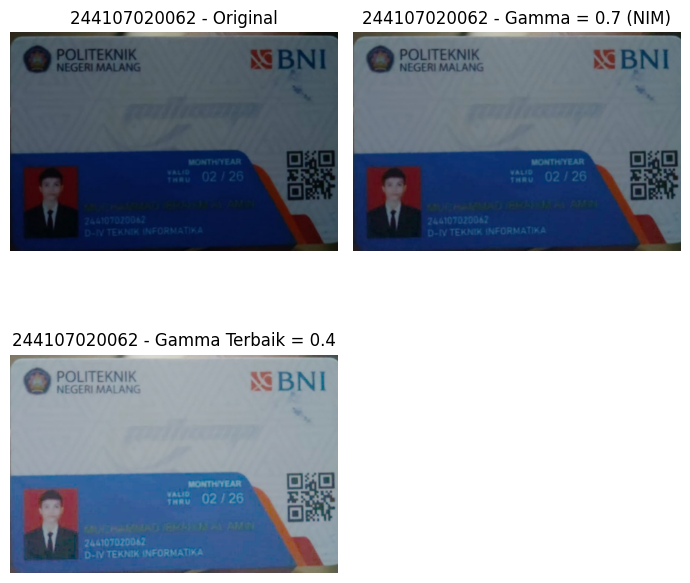

In [77]:
#6 Gamma Correction pada Citra Pribadi
foto_bgr = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/KTM1a.jpg')
foto_rgb = cv.cvtColor(foto_bgr, cv.COLOR_BGR2RGB)

print('Mengubah Gamma Citra')
print('--------------------------------')

try:
  gamma = float(input("Masukkan Nilai Gamma: "))
  foto_norm = foto_rgb / 255.0

  hasil_gamma = np.uint8(np.clip((foto_norm ** gamma) * 255, 0, 255))
  hasil_gamma_nim = np.uint8(np.clip((foto_norm ** 0.7) * 255, 0, 255))

  plt.figure(figsize=(7, 7))

  plt.subplot(2, 2, 1)
  plt.title(f"{NIM} - Original")
  plt.imshow(foto_rgb)
  plt.axis('off')

  plt.subplot(2, 2, 2)
  plt.title(f"{NIM} - Gamma = 0.7 (NIM)")
  plt.imshow(hasil_gamma_nim)
  plt.axis('off')

  plt.subplot(2, 2, 3)
  plt.title(f"{NIM} - Gamma Terbaik = {gamma}")
  plt.imshow(hasil_gamma)
  plt.axis('off')

  plt.tight_layout()
  plt.show()
except ValueError:
  print('Error, Not a number')


Kenapa nilai gamma terbaik setiap mahasiswa beda? karena foto redup yang diambil pencahayaan nya berbeda beda

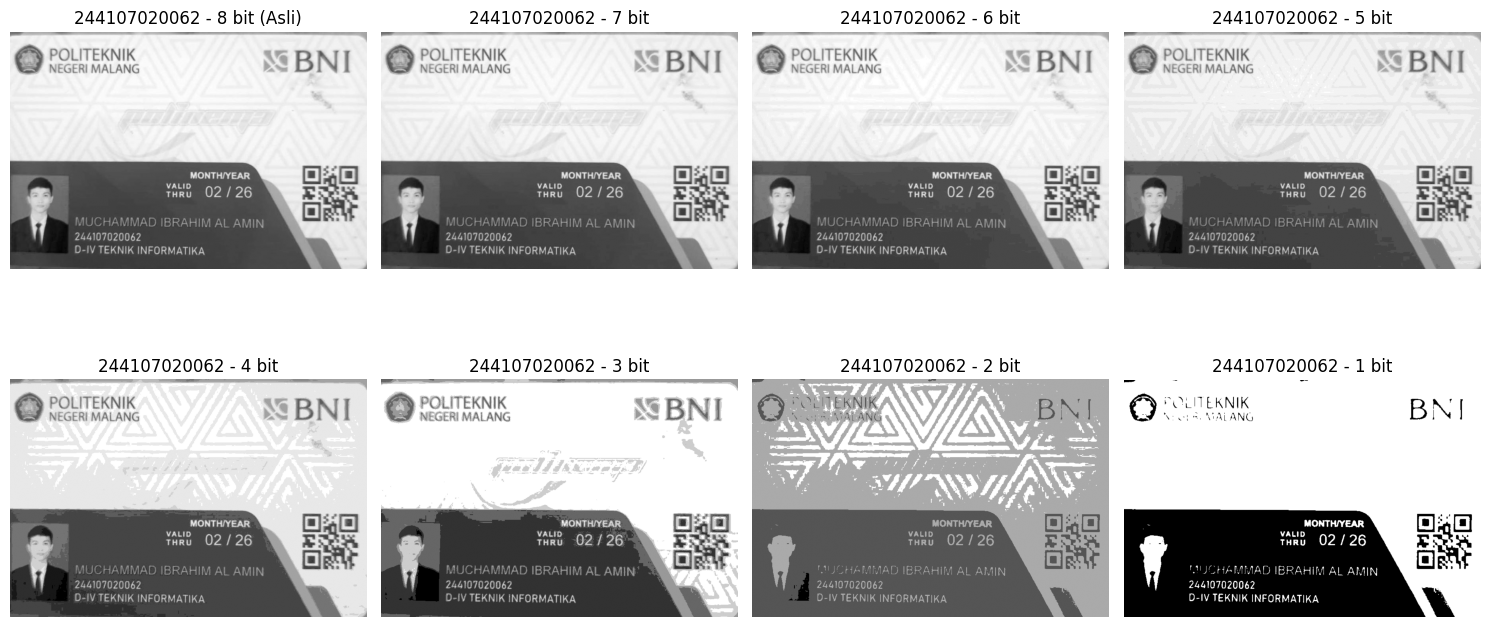

In [90]:
#7. Buat Simulasi Image Depth pada Citra Pribadi

gambar = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.title(f"{NIM} - 8 bit (Asli)")
plt.imshow(gambar, cmap='gray')
plt.axis('off')

nomor_posisi = 2

for bit in [7, 6, 5, 4, 3, 2, 1]:
    interval = 255.0 / (pow(2, bit) - 1)

    hasil = np.round(gambar / interval) * interval
    hasil = hasil.astype(np.uint8)

    plt.subplot(2, 4, nomor_posisi)
    plt.title(f"{NIM} - {bit} bit")
    plt.imshow(hasil, cmap='gray')
    plt.axis('off')

    nomor_posisi = nomor_posisi + 1

plt.tight_layout()
plt.show()

Total gambar yang dibaca: 100
Jumlah: 10 | Nilai PSNR: 19.73 dB
Jumlah: 20 | Nilai PSNR: 19.84 dB
Jumlah: 40 | Nilai PSNR: 19.89 dB
Jumlah: 80 | Nilai PSNR: 19.92 dB
Jumlah: 100 | Nilai PSNR: 19.92 dB


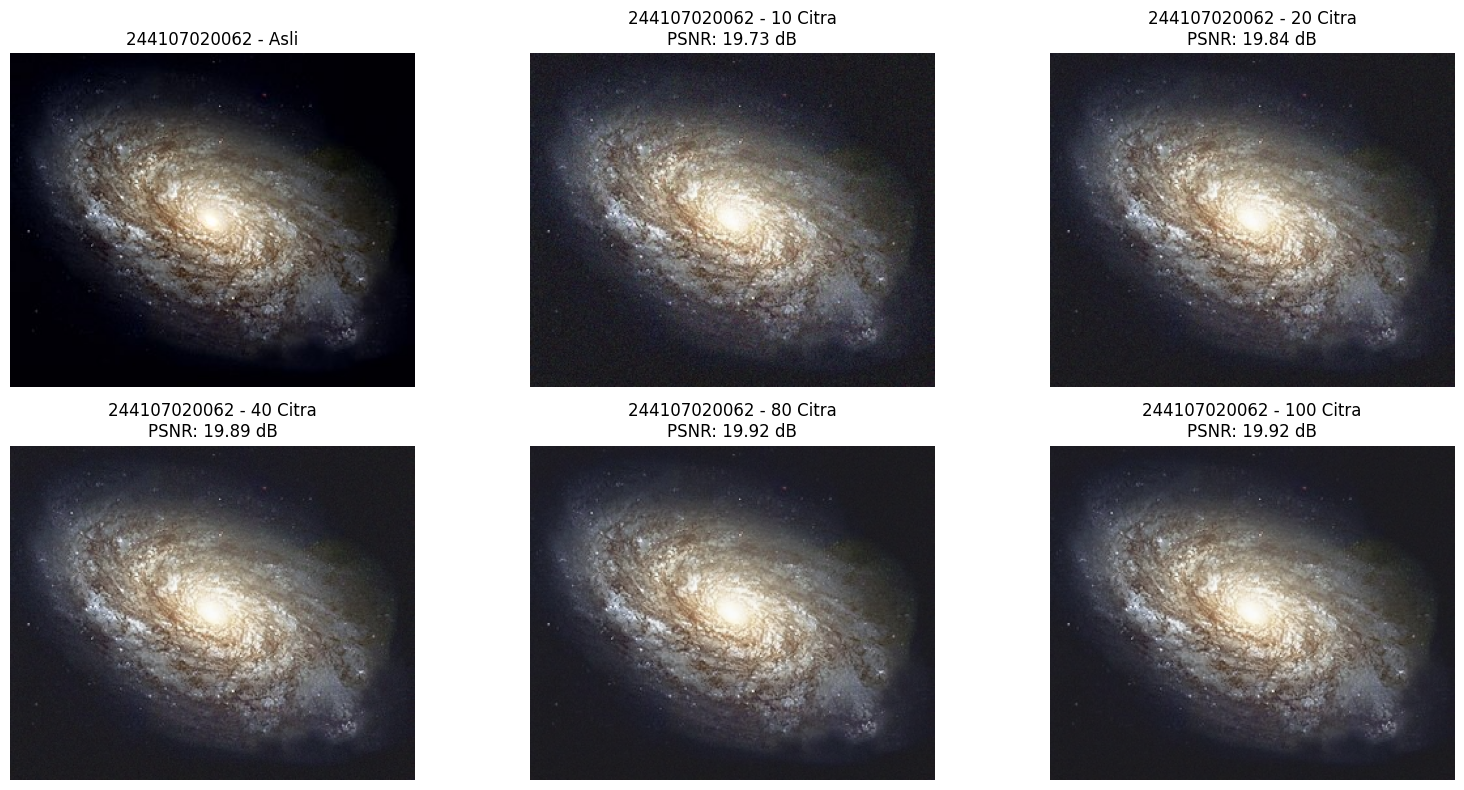

In [92]:
#8. Average Denoising

import glob

path_asli = '/content/drive/MyDrive/PCVK_2026/Minggu 3/galaxy/galaxy.jpg'
citra_asli = cv.imread(path_asli)

cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK_2026/Minggu 3/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

print(f"Total gambar yang dibaca: {len(cv_img)}")

daftar_k = [10, 20, 40, 80, 100]
hasil_gambar = []
hasil_psnr = []

for k in daftar_k:
    koleksi = cv_img[:k]

    rata_rata = np.mean(koleksi, axis=0)
    rata_rata = np.uint8(np.clip(rata_rata, 0, 255))

    nilai = cv.PSNR(citra_asli, rata_rata)

    hasil_gambar.append(rata_rata)
    hasil_psnr.append(nilai)
    print(f"Jumlah: {k} | Nilai PSNR: {nilai:.2f} dB")

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.title(f"{NIM} - Asli")
plt.imshow(cv.cvtColor(citra_asli, cv.COLOR_BGR2RGB))
plt.axis('off')

for i in range(len(daftar_k)):
    plt.subplot(2, 3, i + 2)
    plt.title(f"{NIM} - {daftar_k[i]} Citra\nPSNR: {hasil_psnr[i]:.2f} dB")
    plt.imshow(cv.cvtColor(hasil_gambar[i], cv.COLOR_BGR2RGB))
    plt.axis('off')

plt.tight_layout()
plt.show()

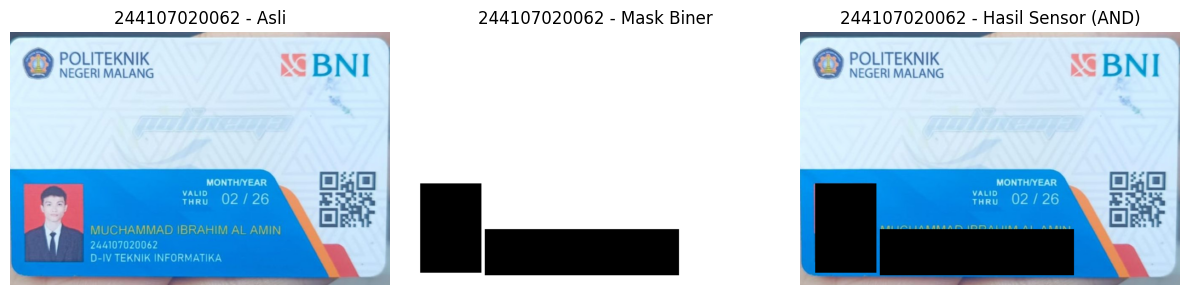

Koordinat Kotak Mask:
- Area Foto Wajah : Titik kiri-atas (36, 360) sampai kanan-bawah (180, 570)
- Area NIM & Nama : Titik kiri-atas (189, 468) sampai kanan-bawah (648, 576)


In [96]:
# 9. Buat Image Masking untuk Penyamaran Data Pribadi

path_ktm = '/content/drive/MyDrive/PCVK_2026/Minggu 3/KTM1d.jpg'
foto_bgr = cv.imread(path_ktm)
foto_rgb = cv.cvtColor(foto_bgr, cv.COLOR_BGR2RGB)

tinggi, lebar = foto_rgb.shape[:2]

mask = np.ones((tinggi, lebar), dtype="uint8") * 255

x1_wajah = int(lebar * 0.04)
y1_wajah = int(tinggi * 0.60)   # dinaikkan dari 0.70 ke 0.60
x2_wajah = int(lebar * 0.20)
y2_wajah = int(tinggi * 0.95)
cv.rectangle(mask, (x1_wajah, y1_wajah), (x2_wajah, y2_wajah), 0, -1)

# 2. Area NIM dan Nama (dinaikkan & dilebarkan agar teks nama + angka NIM tertutup)
x1_nim = int(lebar * 0.21)
y1_nim = int(tinggi * 0.78)     # dinaikkan agar pas di atas teks Nama
x2_nim = int(lebar * 0.72)     # dilebarkan ke kanan mengikuti panjang nama
y2_nim = int(tinggi * 0.96)     # menutup sampai bawah angka NIM
cv.rectangle(mask, (x1_nim, y1_nim), (x2_nim, y2_nim), 0, -1)

hasil_sensor = cv.bitwise_and(foto_rgb, foto_rgb, mask=mask)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title(f"{NIM} - Asli")
plt.imshow(foto_rgb)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f"{NIM} - Mask Biner")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"{NIM} - Hasil Sensor (AND)")
plt.imshow(hasil_sensor)
plt.axis('off')

plt.tight_layout()
plt.show()

print("Koordinat Kotak Mask:")
print(f"- Area Foto Wajah : Titik kiri-atas ({x1_wajah}, {y1_wajah}) sampai kanan-bawah ({x2_wajah}, {y2_wajah})")
print(f"- Area NIM & Nama : Titik kiri-atas ({x1_nim}, {y1_nim}) sampai kanan-bawah ({x2_nim}, {y2_nim})")

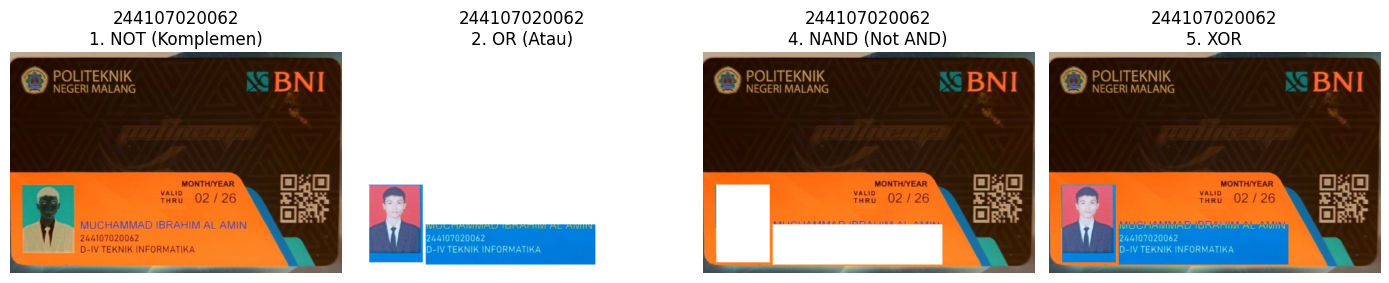

In [97]:
# Ubah masker menjadi 3 channel agar cocok dengan gambar RGB
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2RGB)
hasil_and = cv.bitwise_and(foto_rgb, foto_rgb, mask=mask)


hasil_not  = cv.bitwise_not(foto_rgb)
hasil_or   = cv.bitwise_or(foto_rgb, mask_3ch)
hasil_nand = cv.bitwise_not(hasil_and)
hasil_xor  = cv.bitwise_xor(foto_rgb, mask_3ch)

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.title(f"{NIM}\n1. NOT (Komplemen)")
plt.imshow(hasil_not)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title(f"{NIM}\n2. OR (Atau)")
plt.imshow(hasil_or)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title(f"{NIM}\n4. NAND (Not AND)")
plt.imshow(hasil_nand)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title(f"{NIM}\n5. XOR")
plt.imshow(hasil_xor)
plt.axis('off')

plt.tight_layout()
plt.show()

NOT (Komplemen):
Warna gambar terbalik total seperti klise foto film karena semua nilai piksel dibalik (255 dikurangi nilai asli). Masker tidak digunakan pada operasi ini.

OR (Atau):
Latar kartu menjadi putih polos karena warna asli digabung dengan area masker putih (nilai 255). Sebaliknya, area wajah dan teks tetap muncul normal seperti aslinya karena bertemu kotak hitam (nilai 0).

AND (Dan):
Latar kartu tetap normal karena bertemu area masker putih (nilai 255). Sementara bagian wajah dan teks tertutup balok hitam pekat karena bertemu kotak hitam (nilai 0), sehingga data pribadi berhasil tersensor.

NAND (Not AND):
Merupakan kebalikan dari operasi AND. Area latar kartu berubah menjadi klise negatif, sedangkan bagian wajah dan teks yang tadinya hitam berubah menjadi balok putih terang.

XOR (Exclusive OR):
Latar kartu berubah menjadi tampilan negatif karena bertemu warna putih pada masker. Sementara area wajah dan teks tetap tampil normal seperti aslinya karena bertemu kotak hitam.

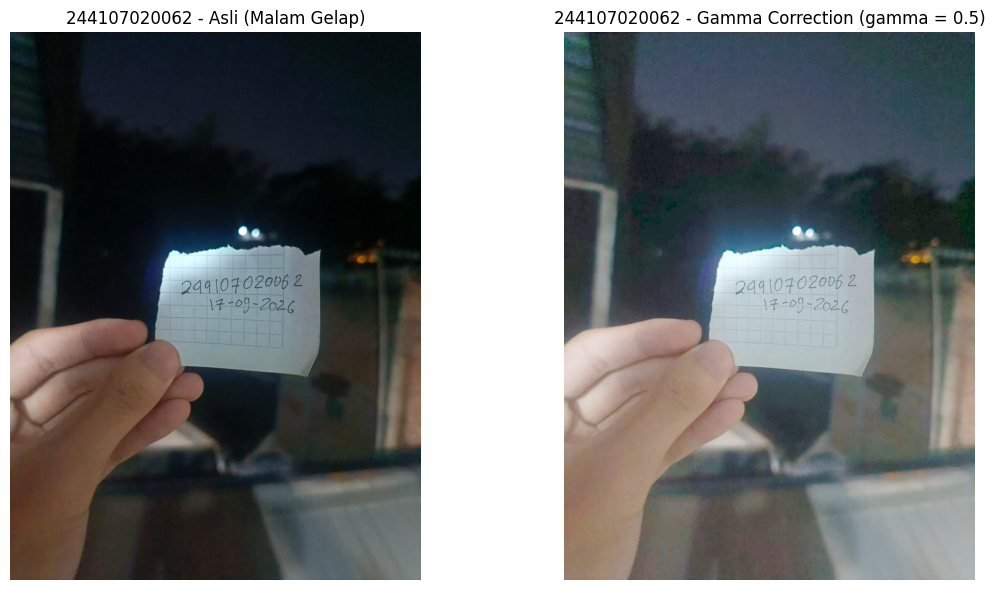

In [99]:
#10. Foto Malam Hari
foto_bgr = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/NIGHT1.jpg')
foto_rgb = cv.cvtColor(foto_bgr, cv.COLOR_BGR2RGB)

foto_norm = foto_rgb / 255.0

gamma = 0.5
hasil_gamma = np.power(foto_norm, gamma) * 255.0
hasil_gamma = np.uint8(np.clip(hasil_gamma, 0, 255))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"{NIM} - Asli (Malam Gelap)")
plt.imshow(foto_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"{NIM} - Gamma Correction (gamma = {gamma})")
plt.imshow(hasil_gamma)
plt.axis('off')

plt.tight_layout()
plt.show()

Alasannya karena bagian kertas dan tangan sudah cukup terang, sedangkan latar belakangnya sangat gelap. Kalau memakai pencerahan biasa, kertas putihnya bakal silau dan tulisan NIM-nya malah hilang terbakar. Dengan gamma correction, jadi bisa mengangkat area yang gelap saja supaya detail latar belakang kelihatan, tanpa merusak atau membuat silau area kertas yang sudah terang.

Resiko
- Bintik-bintik noise atau bintik pasir pada area gelap dan langit malam akan ikut terangkat dan jadi lebih kelihatan jelas.

- Kalau nilai gamma dipasang terlalu rendah, gambar bisa terlihat berkabut atau agak pudar karena warna hitam pekatnya hilang.

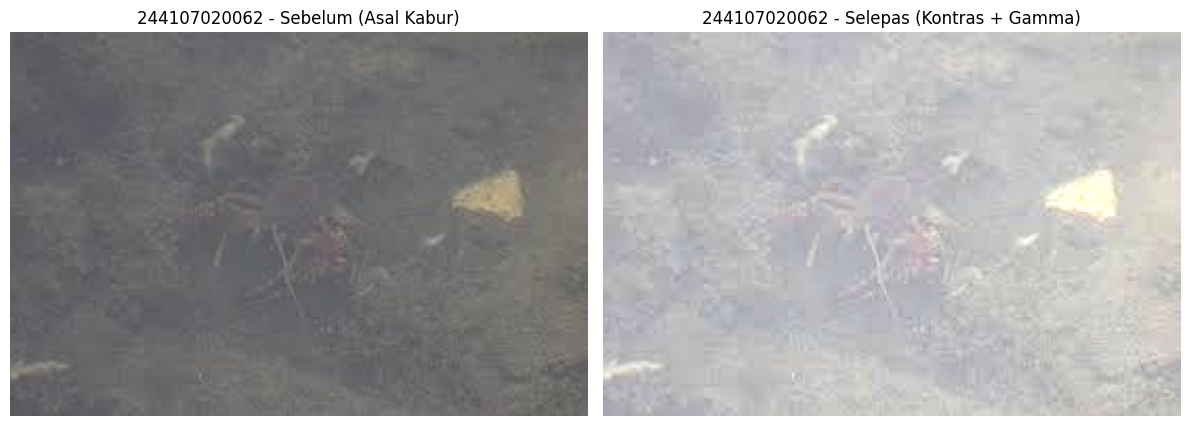

In [101]:
#Perbaiki gambar
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

imej_bgr = cv.imread('/content/drive/MyDrive/PCVK_2026/Minggu 3/perbaikan.jpg')
imej_rgb = cv.cvtColor(imej_bgr, cv.COLOR_BGR2RGB)

alpha = 1.8
beta = -20
imej_kontras = cv.convertScaleAbs(imej_rgb, alpha=alpha, beta=beta)

gamma = 0.7
imej_norm = imej_kontras / 255.0
imej_gamma = np.power(imej_norm, gamma) * 255.0
imej_hasil = np.uint8(np.clip(imej_gamma, 0, 255))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"{NIM} - Sebelum (Asal Kabur)")
plt.imshow(imej_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"{NIM} - Selepas (Kontras + Gamma)")
plt.imshow(imej_hasil)
plt.axis('off')

plt.tight_layout()
plt.show()

Metode yang dipake yaitu Gabungan Contrast Stretching (Linear Transform) dan Gamma Correction karena gambar doksli sangat pudar, kemudian memakai nilai Nilai alpha dipilih 1.7 untuk menaikkan ketajaman warna udang, dan beta diletakkan -15 untuk membuang kesan kabus putih yang berlebihan pada air